<a href="https://colab.research.google.com/github/Foysal061/EmergencyDepartmentPatientPred/blob/main/LSTMWithOptuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#pip install openmeteo-requests requests-cache retry-requests numpy pandas tensorflow scikit-learn optuna optuna_integration
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime, timedelta
import openmeteo_requests
import requests_cache
from retry_requests import retry
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import json
import warnings
warnings.filterwarnings('ignore')

In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths (MODIFY THESE FOR YOUR SETUP)
ED_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/VestfoldTriageReport.csv"
INFECTION_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Infeksjonsdata.xlsx"

# Hospital coordinates (Vestfold Hospital, Tønsberg)
HOSPITAL_LAT = 59.2725
HOSPITAL_LON = 10.4184

# Optuna configuration
USE_OPTUNA = True  # Set to False to skip optimization
OPTUNA_N_TRIALS = 50  # Number of optimization trials
OPTUNA_TIMEOUT = 7200  # Timeout in seconds (2 hours)

# Feature engineering
USE_LAG_FEATURES = True
LOOKBACK = 24  # Hours to look back for LSTM

# Manual hyperparameters (used if USE_OPTUNA = False)
MANUAL_PARAMS = {
    'n_layers': 2,
    'hidden_size': 128,
    'dropout_rate': 0.1,
    'dense_layers': 2,
    'dense_units': 16,
    'learning_rate': 0.0004,
    'batch_size': 32,
    'l2_reg': 0.01,
    'batch_norm': True,
    'optimizer': 'rmsprop'
}


In [4]:
def load_ed_data(filepath, separator=';'):
    """Load ED data from CSV"""
    print("\n[1/10] Loading ED data...")
    df = pd.read_csv(filepath, sep=separator)
    df.columns = ['arrival', 'departure', 'first_doctor_response', 'first_triage']
    print(f"   Loaded {len(df)} records")
    print("\nFirst 5 rows:")
    print(df.head())
    return df

# Load data
df = load_ed_data(ED_DATA_PATH)

print("\nData shape:", df.shape)
print("Columns:", df.columns.tolist())


[1/10] Loading ED data...
   Loaded 35674 records

First 5 rows:
            arrival         departure first_doctor_response   first_triage
0  01.10.2023 13:46  06.10.2023 18:10            LessUrgent  Resuscitation
1  01.10.2023 14:20  20.10.2023 11:37            LessUrgent     LessUrgent
2  01.10.2023 13:59  03.10.2023 12:04                   NaN  Resuscitation
3  01.10.2023 14:40  01.10.2023 17:30            LessUrgent     LessUrgent
4  01.10.2023 13:50  01.10.2023 20:45             NotUrgent         Urgent

Data shape: (35674, 4)
Columns: ['arrival', 'departure', 'first_doctor_response', 'first_triage']


In [5]:
def parse_datetime_columns(df):
    """Parse and convert datetime columns"""
    print("\n[2/10] Parsing datetime fields...")

    df['arrival'] = pd.to_datetime(df['arrival'], format='%d.%m.%Y %H:%M', errors='coerce')
    df['departure'] = pd.to_datetime(df['departure'], format='%d.%m.%Y %H:%M', errors='coerce')

    df = df.dropna(subset=['arrival', 'departure'])
    df = df.sort_values('arrival')

    local_zone = 'Europe/Oslo'
    df['arrival'] = df['arrival'].dt.tz_localize(local_zone).dt.tz_convert('UTC').dt.tz_localize(None)
    df['departure'] = df['departure'].dt.tz_localize(local_zone).dt.tz_convert('UTC').dt.tz_localize(None)

    df['duration_hour'] = (df['departure'] - df['arrival']).dt.total_seconds() / (60*60)

    print(f"   Parsed {len(df)} records")
    print(f"   Date range: {df['arrival'].min()} to {df['arrival'].max()}")
    return df

df = parse_datetime_columns(df)

print("\nSample data after parsing:")
print(df.head())


[2/10] Parsing datetime fields...
   Parsed 35674 records
   Date range: 2023-10-01 11:46:00 to 2024-10-25 10:35:00

Sample data after parsing:
              arrival           departure first_doctor_response  \
0 2023-10-01 11:46:00 2023-10-06 16:10:00            LessUrgent   
4 2023-10-01 11:50:00 2023-10-01 18:45:00             NotUrgent   
7 2023-10-01 11:59:00 2023-10-05 13:05:00                Urgent   
2 2023-10-01 11:59:00 2023-10-03 10:04:00                   NaN   
8 2023-10-01 12:20:00 2023-10-02 12:01:00            LessUrgent   

    first_triage  duration_hour  
0  Resuscitation     124.400000  
4         Urgent       6.916667  
7  Resuscitation      97.100000  
2  Resuscitation      46.083333  
8  Resuscitation      23.683333  


In [6]:
def aggregate_to_hourly(df):
    """Aggregate data to hourly intervals"""
    print("\n[3/10] Aggregating to hourly intervals...")

    df['arrival_hour'] = df['arrival'].dt.floor('H')

    hourly_df = df.groupby('arrival_hour').agg({
        'arrival': 'count',
        'duration_hour': ['mean', 'std']
    })

    hourly_df.columns = ['arrival_count', 'duration_mean', 'duration_std']
    hourly_df = hourly_df.reset_index()
    hourly_df[['duration_mean', 'duration_std']] = hourly_df[['duration_mean', 'duration_std']].fillna(0)
    hourly_df['first_doctor_response'] = df['first_doctor_response'].fillna('Unknown')
    hourly_df['first_triage'] = df['first_triage'].fillna('Unknown')

    print(f"   Created {len(hourly_df)} hourly records")
    return hourly_df

df = aggregate_to_hourly(df)

print("\nHourly aggregated data:")
print(df.head(10))


[3/10] Aggregating to hourly intervals...
   Created 8284 hourly records

Hourly aggregated data:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   
5 2023-10-01 16:00:00              3       3.961111      1.736242   
6 2023-10-01 17:00:00              2      20.550000      2.734146   
7 2023-10-01 18:00:00              5      76.573333     69.082435   
8 2023-10-01 19:00:00              4      76.704167    104.066427   
9 2023-10-01 20:00:00              2     124.100000     87.186266   

  first_doctor_response   first_triage  
0            LessUrgent  Resuscitation  
1            LessUrgent     LessUrgent  
2               Un

In [7]:
def fetch_weather_data(start_date, end_date):
    """Fetch weather data from Open-Meteo API in UTC timezone"""
    print(f"\n[4/10] Fetching weather data...")

    cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": HOSPITAL_LAT,
        "longitude": HOSPITAL_LON,
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "UTC",  # Set timezone to UTC
        "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation",
                  "surface_pressure", "wind_speed_10m"]
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    hourly = response.Hourly()

    timestamps = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s"),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )

    weather_df = pd.DataFrame({
        "date": timestamps,
        "temperature": hourly.Variables(0).ValuesAsNumpy().astype(float).round(2),
        "humidity": hourly.Variables(1).ValuesAsNumpy().astype(float).round(2),
        "precipitation": hourly.Variables(2).ValuesAsNumpy().astype(float).round(2),
        "pressure": hourly.Variables(3).ValuesAsNumpy().astype(float).round(2),
        "wind_speed": hourly.Variables(4).ValuesAsNumpy().astype(float).round(2)
    })

    weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None)
    print(f"   Fetched {len(weather_df)} weather records")
    print(f"   Timezone: UTC")
    return weather_df

# Fetch weather data (adjust dates based on your data)
weather_df = fetch_weather_data("2023-01-10", "2024-10-26")

print("\nWeather data sample:")
print(weather_df.head())


[4/10] Fetching weather data...
   Fetched 15744 weather records
   Timezone: UTC

Weather data sample:
                 date  temperature  humidity  precipitation  pressure  \
0 2023-01-10 00:00:00         1.40     98.58            0.0    995.77   
1 2023-01-10 01:00:00         1.65     98.93            0.0    996.47   
2 2023-01-10 02:00:00         1.85     97.53            0.0    997.27   
3 2023-01-10 03:00:00         1.70     96.48            0.0    997.77   
4 2023-01-10 04:00:00         0.55     98.92            0.0    998.36   

   wind_speed  
0        6.88  
1        7.42  
2        7.93  
3        5.62  
4        3.32  


In [8]:
def merge_weather_data(df, weather_df):
    """Merge weather data with ED data"""
    print("\n[5/10] Merging weather data...")

    df['arrival_hour'] = pd.to_datetime(df['arrival_hour'])
    weather_df['date'] = pd.to_datetime(weather_df['date'])

    merged_df = pd.merge_asof(
        df.sort_values("arrival_hour"),
        weather_df.sort_values("date"),
        left_on="arrival_hour",
        right_on="date",
        direction="nearest"
    )

    merged_df = merged_df.drop(columns=['date'], errors='ignore')
    print(f"   Merged to {len(merged_df)} records")
    print(f"   Total columns: {len(merged_df.columns)}")
    return merged_df

df = merge_weather_data(df, weather_df)

print("\nMerged data sample:")
print(df.head())


[5/10] Merging weather data...
   Merged to 8284 records
   Total columns: 11

Merged data sample:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   

  first_doctor_response   first_triage  temperature  humidity  precipitation  \
0            LessUrgent  Resuscitation        15.90     65.10            0.0   
1            LessUrgent     LessUrgent        14.90     58.57            0.0   
2               Unknown  Resuscitation        15.05     59.01            0.0   
3            LessUrgent     LessUrgent        14.50     63.26            0.0   
4             NotUrgent         Urgent        13.65     66.62            0.0   

   p

In [9]:
def load_merge_infection_data(df):
    """Load and merge infection data - convert to hourly averages"""
    print("\n[6/10] Loading infection data...")

    monthly_df = pd.read_excel(INFECTION_DATA_PATH, header=0)

    print(f"   Loaded {len(monthly_df)} months of infection data")
    print(f"   Columns: {list(monthly_df.columns)}")
    print("\n   Sample infection data:")
    print(monthly_df.head())

    # Parse Month column
    monthly_df['Month'] = pd.to_datetime(monthly_df['Month'], format='%b-%y')

    # Create year_month for merging
    df['year_month'] = df['arrival_hour'].dt.to_period('M')
    monthly_df['year_month'] = monthly_df['Month'].dt.to_period('M')

    # Merge
    df_merged = df.merge(
        monthly_df[['year_month', 'Total_Infected_Patient_Monthly']],
        on='year_month',
        how='left'
    )

    # Convert to hourly averages
    print(f"\n   Converting monthly infection counts to hourly averages...")
    hours_in_month = df_merged['arrival_hour'].dt.days_in_month * 24
    df_merged['infection_rate_hourly'] = (
        df_merged['Total_Infected_Patient_Monthly'] / hours_in_month
    )

    # Drop temporary columns
    df_merged = df_merged.drop(columns=['Total_Infected_Patient_Monthly', 'year_month'])

    print(f"   Created 'infection_rate_hourly' feature")


    return df_merged

df = load_merge_infection_data(df)

print("\nData with infection rates:")
print(df.head(10))


[6/10] Loading infection data...
   Loaded 24 months of infection data
   Columns: ['Month', 'Total_Infected_Patient_Monthly']

   Sample infection data:
       Month  Total_Infected_Patient_Monthly
0 2023-10-01                             616
1 2023-11-01                             924
2 2023-12-01                            1175
3 2024-01-01                            1026
4 2024-02-01                            1163

   Converting monthly infection counts to hourly averages...
   Created 'infection_rate_hourly' feature

Data with infection rates:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   
5 2023-10-01 16:00:00       

In [10]:
def fetch_norwegian_holidays(start_year, end_year):
    """Fetch Norwegian public holidays"""
    print(f"\n[7/10] Fetching Norwegian holidays {start_year}-{end_year}...")

    all_holidays = []
    for year in range(start_year, end_year + 1):
        try:
            url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/NO"
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                holidays = response.json()
                for holiday in holidays:
                    all_holidays.append({'date': pd.to_datetime(holiday['date'])})
                print(f"     {year}: {len(holidays)} holidays")
        except:
            print(f"     {year}: Failed")

    if not all_holidays:
        return pd.DataFrame(columns=['date'])

    holidays_df = pd.DataFrame(all_holidays).drop_duplicates(subset=['date'])
    print(f"   Total: {len(holidays_df)} unique holidays")
    return holidays_df

def add_holiday_feature(df):
    """Add is_holiday feature"""
    start_year = df['arrival_hour'].dt.year.min()
    end_year = df['arrival_hour'].dt.year.max()

    holidays_df = fetch_norwegian_holidays(start_year, end_year)

    if holidays_df.empty:
        df['is_holiday'] = 0
    else:
        df['_date'] = pd.to_datetime(df['arrival_hour']).dt.date
        holidays_df['_date'] = holidays_df['date'].dt.date
        holiday_dates = set(holidays_df['_date'])
        df['is_holiday'] = df['_date'].isin(holiday_dates).astype(int)
        df = df.drop(columns=['_date'])

    n_holidays = df['is_holiday'].sum()
    print(f"   Holiday hours: {n_holidays} ({n_holidays/len(df)*100:.1f}%)")

    return df

df = add_holiday_feature(df)

print("\nData with holiday feature:")
print(df[['arrival_hour', 'arrival_count', 'is_holiday']].head(20))


[7/10] Fetching Norwegian holidays 2023-2024...
     2023: 12 holidays
     2024: 12 holidays
   Total: 24 unique holidays
   Holiday hours: 259 (3.1%)

Data with holiday feature:
          arrival_hour  arrival_count  is_holiday
0  2023-10-01 11:00:00              4           0
1  2023-10-01 12:00:00              6           0
2  2023-10-01 13:00:00              6           0
3  2023-10-01 14:00:00              3           0
4  2023-10-01 15:00:00              6           0
5  2023-10-01 16:00:00              3           0
6  2023-10-01 17:00:00              2           0
7  2023-10-01 18:00:00              5           0
8  2023-10-01 19:00:00              4           0
9  2023-10-01 20:00:00              2           0
10 2023-10-01 21:00:00              1           0
11 2023-10-01 22:00:00              1           0
12 2023-10-01 23:00:00              1           0
13 2023-10-02 02:00:00              1           0
14 2023-10-02 03:00:00              1           0
15 2023-10-02 04:00

In [11]:
def create_temporal_features(df):
    """Create temporal features"""
    print("\n[8/10] Creating temporal features...")

    df['hour'] = df['arrival_hour'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day'] = df['arrival_hour'].dt.day
    df['dayofweek'] = df['arrival_hour'].dt.dayofweek
    df['week'] = df['arrival_hour'].dt.isocalendar().week
    df['month'] = df['arrival_hour'].dt.month
    df['year'] = df['arrival_hour'].dt.year
    df['day_of_year'] = df['arrival_hour'].dt.dayofyear
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_monday'] = (df['dayofweek'] == 0).astype(int)
    df['is_friday'] = (df['dayofweek'] == 4).astype(int)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        # Time of day categories
    df['time_of_day'] = pd.cut(
        df['hour'],
        bins=[-1, 6, 12, 18, 24],
        labels=['night', 'morning', 'afternoon', 'evening']
    )

    # Shift patterns
    df['shift'] = pd.cut(
        df['hour'],
        bins=[-1, 8, 16, 24],
        labels=['night_shift', 'day_shift', 'evening_shift']
    )
    df['same_hour_last_week'] = df['arrival_count'].shift(168)
    df['same_hour_2weeks_ago'] = df['arrival_count'].shift(336)
    df['diff_from_last_week'] = (
        df['arrival_count'] - df['same_hour_last_week']
    )
    df['arrival_change_1h'] = df['arrival_count'].diff(1)
    df['arrival_change_3h'] = df['arrival_count'].diff(3)
    df['arrival_pct_change_1h'] = df['arrival_count'].pct_change(1)
    df['arrival_pct_change_24h'] = df['arrival_count'].pct_change(24)
    df['ema_12h'] = df['arrival_count'].ewm(span=12).mean()
    df['ema_24h'] = df['arrival_count'].ewm(span=24).mean()
    df['first_doctor_response'] = df['first_doctor_response'].astype('category')
    df['first_triage'] = df['first_triage'].astype('category')
    df['time_of_day'] = df['time_of_day'].astype('category')
    df['shift'] = df['shift'].astype('category')

    df['first_doctor_response'] = df['first_doctor_response'].cat.codes
    df['first_triage'] = df['first_triage'].cat.codes
    df['time_of_day'] = df['time_of_day'].cat.codes
    df['shift'] = df['shift'].cat.codes

    print(f"   Created temporal features")
    return df

df = create_temporal_features(df)

print(f"\nTotal columns now: {len(df.columns)}")
print("Temporal features:")
temporal_cols = [col for col in df.columns if any(x in col for x in ['hour', 'day', 'week', 'month', 'sin', 'cos'])]
print(temporal_cols)


[8/10] Creating temporal features...
   Created temporal features

Total columns now: 44
Temporal features:
['arrival_hour', 'infection_rate_hourly', 'is_holiday', 'hour', 'hour_sin', 'hour_cos', 'day', 'dayofweek', 'week', 'month', 'day_of_year', 'is_weekend', 'is_monday', 'is_friday', 'day_sin', 'day_cos', 'dayofweek_sin', 'dayofweek_cos', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'time_of_day', 'same_hour_last_week', 'same_hour_2weeks_ago', 'diff_from_last_week']


In [12]:
def create_lag_features(df, target_col='arrival_count', lags=[1, 6, 12, 24]):
    """Create lag features"""
    print(f"\n   Creating lag features for {target_col}...")
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    df[f'{target_col}_next'] = df[target_col].shift(-1)
    df = df.dropna()
    print(f"   Created lag features: {lags}")
    return df

if USE_LAG_FEATURES:
    df = create_lag_features(df, 'arrival_count', [1, 6, 12, 24])
    TARGET_COL = 'arrival_count_next'
    exclude_cols = ['arrival_hour', 'arrival_count_next']
else:
    TARGET_COL = 'arrival_count'
    exclude_cols = ['arrival_hour', 'arrival_count']

print(f"\nTarget column: {TARGET_COL}")
print(f"Data shape after lag features: {df.shape}")
print(f"\nLag features created:")
lag_cols = [col for col in df.columns if 'lag' in col]
print(lag_cols)


   Creating lag features for arrival_count...
   Created lag features: [1, 6, 12, 24]

Target column: arrival_count_next
Data shape after lag features: (7947, 49)

Lag features created:
['arrival_count_lag_1', 'arrival_count_lag_6', 'arrival_count_lag_12', 'arrival_count_lag_24']


In [13]:
def prepare_sequences(df, target_col, lookback, exclude_cols):
    """Prepare sequences for LSTM"""
    print(f"\n[9/10] Preparing sequences...")
    print(f"   Lookback: {lookback} hours")

    feature_cols = [col for col in df.columns if col not in exclude_cols]
    print(f"   Features: {len(feature_cols)}")

    features = df[feature_cols].values
    target = df[target_col].values

    # Scale
    scaler_X = RobustScaler()
    features_scaled = scaler_X.fit_transform(features)

    scaler_y = RobustScaler()
    target_scaled = scaler_y.fit_transform(target.reshape(-1, 1)).flatten()
    target_scaled = np.clip(target_scaled, 0, None)

    # Create sequences
    X, y = [], []
    for i in range(lookback, len(features_scaled)):
        X.append(features_scaled[i-lookback:i])
        y.append(target_scaled[i])

    X = np.array(X)
    y = np.array(y)

    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")

    return X, y, scaler_X, scaler_y, feature_cols

X, y, scaler_X, scaler_y, feature_cols = prepare_sequences(
    df, TARGET_COL, LOOKBACK, exclude_cols
)

print(f"\nSequences created successfully!")
print(f"X shape: {X.shape} (samples, timesteps, features)")
print(f"y shape: {y.shape}")


[9/10] Preparing sequences...
   Lookback: 24 hours
   Features: 47
   X shape: (7923, 24, 47)
   y shape: (7923,)

Sequences created successfully!
X shape: (7923, 24, 47) (samples, timesteps, features)
y shape: (7923,)


In [14]:
# Split data
def train_test_split_temporal(X, y, train_size=0.8, val_size=0.10):
    """Split data maintaining temporal order"""
    n = len(X)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))

    X_train = X[:train_end]
    y_train = y[:train_end]
    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]
    X_test = X[val_end:]
    y_test = y[val_end:]

    print(f"\n  Data Split:")
    print(f"    • Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"    • Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
    print(f"    • Testing: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = train_test_split_temporal(X, y)


  Data Split:
    • Training: 6338 samples (80.0%)
    • Validation: 792 samples (10.0%)
    • Testing: 793 samples (10.0%)


In [15]:
def build_lstm_model_optuna(trial, input_shape):
    """
    FIX #2: Use MSE loss (same as plain LSTM) instead of Huber
    FIX #5: Allow per-layer LSTM sizes (decreasing) instead of single hidden_size
    FIX #6: Explicit dense unit suggestions instead of division
    """
    n_layers = trial.suggest_int('n_layers', 1, 3)

    # FIX #5: Per-layer hidden sizes, each layer can be smaller than the previous
    # INSIDE build_lstm_model_optuna, replace the hidden_sizes loop with:

    ALL_HIDDEN_SIZES = [32, 64, 128, 256]

    hidden_sizes = []
    for i in range(n_layers):
        raw = trial.suggest_categorical(f'hidden_size_{i}', ALL_HIDDEN_SIZES)
        if i > 0:
            raw = min(raw, hidden_sizes[i-1])  # enforce decreasing
        hidden_sizes.append(raw)

    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4, step=0.05)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)
    l2_reg = trial.suggest_categorical('l2_reg', [0.001, 0.005, 0.01, 0.02])
    batch_norm = trial.suggest_categorical('batch_norm', [True, False])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])

    # FIX #6: Explicit dense units instead of dividing (avoids degenerate layers)
    n_dense = trial.suggest_int('dense_layers', 1, 2)
    ALL_DENSE_UNITS = [8, 16, 32, 64]

    dense_units = []
    for i in range(n_dense):
        raw = trial.suggest_categorical(f'dense_units_{i}', ALL_DENSE_UNITS)
        dense_units.append(raw)

    model = keras.Sequential()

    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        kwargs = dict(
            units=hidden_sizes[i],
            return_sequences=return_sequences,
            kernel_regularizer=keras.regularizers.l2(l2_reg),
        )
        if i == 0:
            kwargs['input_shape'] = input_shape
        model.add(layers.LSTM(**kwargs))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
        if batch_norm:
            model.add(layers.BatchNormalization())

    for i in range(n_dense):
        model.add(layers.Dense(dense_units[i], activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l2_reg)))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate * 0.3))  # lighter dropout on dense

    model.add(layers.Dense(1, activation='linear'))

    if optimizer_name == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)

    # FIX #2: Use MSE loss — same as your plain LSTM
    # Original used Huber which optimizes a different objective
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


# =============================================================================
# CORRECTED OPTUNA OPTIMIZATION
# =============================================================================

if USE_OPTUNA:
    print("\n" + "="*80)
    print("OPTUNA HYPERPARAMETER OPTIMIZATION")
    print("="*80)

    def optuna_objective(trial):
        keras.backend.clear_session()

        input_shape = (X_train.shape[1], X_train.shape[2])
        model = build_lstm_model_optuna(trial, input_shape)

        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

        # FIX #3: Add early stopping to trials so they converge properly
        # Original: 30 epochs, no callbacks → noisy signal for Optuna
        early_stop_trial = EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, mode='min'
        )

        # FIX #4: Use the SAME validation set as final training
        # Original: used its own 85/15 split, different from the 80/10/10 final split
        try:
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),       # FIX #4: same val set
                epochs=60,                              # FIX #3: more epochs allowed
                batch_size=batch_size,
                callbacks=[early_stop_trial],           # FIX #3: early stopping
                shuffle=False,
                verbose=0
            )

            best_val_loss = min(history.history['val_loss'])
            return best_val_loss
        except Exception as e:
            print(f"  Trial failed: {e}")
            raise optuna.exceptions.TrialPruned()

    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5)
    )

    try:
        study.optimize(
            optuna_objective,
            n_trials=OPTUNA_N_TRIALS,
            timeout=OPTUNA_TIMEOUT,
            show_progress_bar=True,
            catch=(Exception,)
        )

        if study.best_trial:
            print(f"\n Best trial: #{study.best_trial.number}")
            print(f" Val loss: {study.best_trial.value:.6f}")
            best_params = study.best_params
        else:
            print("\n No successful trials, using manual params")
            best_params = MANUAL_PARAMS
    except:
        print("\n Optimization failed, using manual params")
        best_params = MANUAL_PARAMS
else:
    print("\n Using manual hyperparameters (skipping Optuna)")
    best_params = MANUAL_PARAMS

with open('best_hyperparameters.json', 'w') as f:
    json.dump(best_params, f, indent=4)
print(f"\n Best Hyperparameters:")
for k, v in best_params.items():
    print(f"   {k}: {v}")

[I 2026-03-23 19:12:49,748] A new study created in memory with name: no-name-92f22097-2bf7-4d77-8a43-3ac523665d6f



OPTUNA HYPERPARAMETER OPTIMIZATION


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-23 19:17:50,714] Trial 0 finished with value: 0.29276761412620544 and parameters: {'n_layers': 2, 'hidden_size_0': 32, 'hidden_size_1': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00010838581269344756, 'l2_reg': 0.001, 'batch_norm': False, 'optimizer': 'adam', 'dense_layers': 1, 'dense_units_0': 8, 'batch_size': 32}. Best is trial 0 with value: 0.29276761412620544.
[I 2026-03-23 19:32:54,238] Trial 1 finished with value: 0.3023589551448822 and parameters: {'n_layers': 2, 'hidden_size_0': 128, 'hidden_size_1': 128, 'dropout_rate': 0.2, 'learning_rate': 0.00014653521030672147, 'l2_reg': 0.001, 'batch_norm': False, 'optimizer': 'rmsprop', 'dense_layers': 1, 'dense_units_0': 64, 'batch_size': 32}. Best is trial 0 with value: 0.29276761412620544.
[I 2026-03-23 19:36:32,006] Trial 2 finished with value: 0.42404571175575256 and parameters: {'n_layers': 2, 'hidden_size_0': 32, 'hidden_size_1': 256, 'dropout_rate': 0.2, 'learning_rate': 0.00030012301808980484, 'l2_re

In [16]:
def build_final_model(params, input_shape):
    """
    FIX #5: Reads per-layer sizes from params
    FIX #6: Reads per-layer dense units from params
    FIX #2: Uses MSE loss
    """
    print("\n" + "="*80)
    print("BUILDING FINAL MODEL")
    print("="*80)

    model = keras.Sequential()

    n_layers = params['n_layers']
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        # FIX #5: per-layer hidden size
        hidden_size = params[f'hidden_size_{i}']
        kwargs = dict(
            units=hidden_size,
            return_sequences=return_sequences,
            kernel_regularizer=keras.regularizers.l2(params['l2_reg']),
        )
        if i == 0:
            kwargs['input_shape'] = input_shape
        model.add(layers.LSTM(**kwargs))
        if params['dropout_rate'] > 0:
            model.add(layers.Dropout(params['dropout_rate']))
        if params['batch_norm']:
            model.add(layers.BatchNormalization())

    # FIX #6: per-layer dense units from params
    n_dense = params['dense_layers']
    for i in range(n_dense):
        model.add(layers.Dense(params[f'dense_units_{i}'], activation='relu',
                               kernel_regularizer=keras.regularizers.l2(params['l2_reg'])))
        if params['dropout_rate'] > 0:
            model.add(layers.Dropout(params['dropout_rate'] * 0.3))

    model.add(layers.Dense(1, activation='linear'))

    if params['optimizer'] == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=params['learning_rate'])
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=params['learning_rate'])

    # FIX #2: MSE loss, matching plain LSTM
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])
    model.summary()
    return model


# =============================================================================
# CORRECTED FINAL TRAINING
# =============================================================================

input_shape = (X_train.shape[1], X_train.shape[2])
model = build_final_model(best_params, input_shape)
early_stopping = EarlyStopping(
    monitor='val_loss', patience=20,
    restore_best_weights=True, verbose=1, mode='min'
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=10, min_lr=1e-7, verbose=1, mode='min'
)
model_checkpoint = ModelCheckpoint(
    'best_model.h5', monitor='val_loss',
    save_best_only=True, verbose=1, mode='min'
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),             # FIX #1: was completely missing
    epochs=100,                                  # FIX #1: was only 50 with no stopping
    batch_size=best_params['batch_size'],
    callbacks=[early_stopping, reduce_lr, model_checkpoint],  # FIX #1: was empty
    shuffle=False,
    verbose=1
)

print("\n Saved: best_model.h5")


BUILDING FINAL MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        28,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,153 (129.50 KB)

 Trainable params: 33,025 (129.00 KB)

...


Epoch 9: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2531 - mae: 0.2870 - mse: 0.2355 - val_loss: 0.2641 - val_mae: 0.3332 - val_mse: 0.2465 - learning_rate: 0.0032
Epoch 10/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2162 - mae: 0.2774 - mse: 0.1988
Epoch 10: val_loss did not improve from 0.26409
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.2524 - mae: 0.2875 - mse: 0.2349 - val_loss: 0.2691 - val_mae: 0.3286 - val_mse: 0.2529 - learning_rate: 0.0032
Epoch 11/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2162 - mae: 0.2780 - mse: 0.1999
Epoch 11: val_loss did not improve from 0.26409
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.2534 - mae: 0.2892 - mse: 0.2365 - val_loss: 0.2780 - val_mae: 0.3263 - val_mse: 0.2607 - learning_rate: 0.0032
Epoch 12/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2145 - mae: 0.2745 - mse: 0.1977
Epoch 12: val_loss improved from 0.26409 to 0.25572, saving model to 


Epoch 12: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2512 - mae: 0.2862 - mse: 0.2340 - val_loss: 0.2557 - val_mae: 0.3181 - val_mse: 0.2403 - learning_rate: 0.0032
Epoch 13/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2120 - mae: 0.2732 - mse: 0.1961
Epoch 13: val_loss did not improve from 0.25572
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2500 - mae: 0.2859 - mse: 0.2336 - val_loss: 0.2627 - val_mae: 0.3319 - val_mse: 0.2473 - learning_rate: 0.0032
Epoch 14/100
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2123 - mae: 0.2752 - mse: 0.1964
Epoch 14: val_loss did not improve from 0.25572
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2496 - mae: 0.2865 - mse: 0.2330 - val_loss: 0.2848 - val_mae: 0.3389 - val_mse: 0.2673 - learning_rate: 0.0032
Epoch 15/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2087 - mae: 0.2719 - mse: 0.1921
Epoch 15: val_loss improved from 0.25572 to 0.24907, saving model to


Epoch 15: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.2458 - mae: 0.2841 - mse: 0.2290 - val_loss: 0.2491 - val_mae: 0.3210 - val_mse: 0.2346 - learning_rate: 0.0032
Epoch 16/100
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2087 - mae: 0.2730 - mse: 0.1935
Epoch 16: val_loss did not improve from 0.24907
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.2453 - mae: 0.2846 - mse: 0.2292 - val_loss: 0.2624 - val_mae: 0.3194 - val_mse: 0.2466 - learning_rate: 0.0032
Epoch 17/100
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2081 - mae: 0.2717 - mse: 0.1928
Epoch 17: val_loss did not improve from 0.24907
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2463 - mae: 0.2853 - mse: 0.2303 - val_loss: 0.2539 - val_mae: 0.3120 - val_mse: 0.2375 - learning_rate: 0.0032
Epoch 18/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2063 - mae: 0.2691 - mse: 0.1901
Epoch 18: val_loss did not improve from 0.24907
100/100 ━━━━━━━━━━━━


Epoch 25: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2420 - mae: 0.2831 - mse: 0.2257 - val_loss: 0.2443 - val_mae: 0.3090 - val_mse: 0.2296 - learning_rate: 0.0032
Epoch 26/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2057 - mae: 0.2700 - mse: 0.1901
Epoch 26: val_loss did not improve from 0.24435
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2392 - mae: 0.2816 - mse: 0.2228 - val_loss: 0.2452 - val_mae: 0.3109 - val_mse: 0.2295 - learning_rate: 0.0032
Epoch 27/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2025 - mae: 0.2676 - mse: 0.1865
Epoch 27: val_loss did not improve from 0.24435
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.2381 - mae: 0.2802 - mse: 0.2214 - val_loss: 0.2476 - val_mae: 0.3197 - val_mse: 0.2306 - learning_rate: 0.0032
Epoch 28/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2073 - mae: 0.2712 - mse: 0.1909
Epoch 28: val_loss did not improve from 0.24435
100/100 ━━━━━━━━━━━━


Epoch 32: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2402 - mae: 0.2825 - mse: 0.2240 - val_loss: 0.2407 - val_mae: 0.3209 - val_mse: 0.2268 - learning_rate: 0.0032
Epoch 33/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2025 - mae: 0.2692 - mse: 0.1872
Epoch 33: val_loss did not improve from 0.24069
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.2362 - mae: 0.2798 - mse: 0.2195 - val_loss: 0.2497 - val_mae: 0.3271 - val_mse: 0.2345 - learning_rate: 0.0032
Epoch 34/100
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2008 - mae: 0.2680 - mse: 0.1852
Epoch 34: val_loss did not improve from 0.24069
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2350 - mae: 0.2787 - mse: 0.2189 - val_loss: 0.2449 - val_mae: 0.3277 - val_mse: 0.2293 - learning_rate: 0.0032
Epoch 35/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2009 - mae: 0.2670 - mse: 0.1850
Epoch 35: val_loss did not improve from 0.24069
100/100 ━━━━━━━━━━━━

In [17]:
# Evaluate one-step-ahead predictions on test set
def evaluate_predictions(y_true, y_pred, scaler, dataset_name=""):
    """Calculate and print evaluation metrics"""
    y_true_original = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    mse = mean_squared_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)
    mape = np.mean(np.abs((y_true_original - y_pred_original) / (y_true_original + 1e-8))) * 100

    print(f"\n{dataset_name} Metrics:")
    print(f"  • RMSE: {rmse:.3f} arrivals")
    print(f"  • MAE: {mae:.3f} arrivals")
    print(f"  • R² Score: {r2:.4f}")
    print(f"  • MAPE: {mape:.2f}%")

    return {'y_true': y_true_original, 'y_pred': y_pred_original,
            'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}
print("\n" + "=" * 80)
print("ONE-STEP-AHEAD EVALUATION")
print("=" * 80)

y_test_pred = model.predict(X_test, verbose=0).flatten()
test_results = evaluate_predictions(y_test, y_test_pred, scaler_y, "Test (One-Step)")


ONE-STEP-AHEAD EVALUATION

Test (One-Step) Metrics:
  • RMSE: 2.095 arrivals
  • MAE: 1.344 arrivals
  • R² Score: 0.2502
  • MAPE: 24.01%


In [18]:
def multi_step_forecast(model, initial_seq, scaler_y, n_steps, feature_cols):
    """
    CORRECTED: Properly align lag features with prediction timing
    """
    lag_indices = {}
    for idx, col in enumerate(feature_cols):
        if 'arrival_count_lag_' in col:
            lag_num = int(col.split('_lag_')[1])
            lag_indices[lag_num] = idx

    predictions = []
    current_seq = initial_seq.copy()
    prediction_buffer = []

    for step in range(n_steps):
        # Predict next value (t+step+1)
        X_input = current_seq.reshape(1, current_seq.shape[0], current_seq.shape[1])
        y_pred_scaled = model.predict(X_input, verbose=0)[0][0]
        y_pred = scaler_y.inverse_transform([[y_pred_scaled]])[0][0]

        predictions.append(y_pred)
        prediction_buffer.append(y_pred_scaled)

        # Prepare features for NEXT prediction (at t+step+2)
        new_features = current_seq[-1].copy()

        # Update lags: For predicting t+step+2, lag_N should be value at t+step+2-N
        for lag_num, lag_idx in lag_indices.items():
            # We need value at: (step+1) - lag_num
            # If this is >= 0, we have a prediction for it
            # If this is < 0, it's in our history (keep existing value)

            position_needed = step + 1 - lag_num  # t+step+2 - lag_num relative to t+1

            if position_needed >= 0 and position_needed < len(prediction_buffer):
                # Use prediction
                new_features[lag_idx] = prediction_buffer[position_needed]
            # else: keep existing historical value

        # Slide window
        current_seq = np.vstack([current_seq[1:], new_features])

    return np.array(predictions)

def evaluate_all_horizons(model, X_test, y_test, scaler_y, feature_cols, horizons=[1, 2, 6, 12, 24]):
    """Evaluate at multiple horizons"""
    print("\n" + "="*80)
    print("MULTI-STEP FORECAST EVALUATION")
    print("="*80)

    results = {}

    for horizon in horizons:
        print(f"\n{'='*80}")
        print(f"HORIZON: {horizon} HOUR(S) AHEAD")
        print(f"{'='*80}")

        all_preds, all_acts = [], []
        n_samples = min(100, len(X_test) - horizon)

        for i in range(n_samples):
            forecast = multi_step_forecast(model, X_test[i], scaler_y, horizon, feature_cols)
            pred = forecast[-1]
            actual = scaler_y.inverse_transform([[y_test[i + horizon - 1]]])[0][0]
            all_preds.append(pred)
            all_acts.append(actual)

        preds = np.array(all_preds)
        acts = np.array(all_acts)

        rmse = np.sqrt(mean_squared_error(acts, preds))
        mae = mean_absolute_error(acts, preds)
        r2 = r2_score(acts, preds)
        mape = np.mean(np.abs((acts - preds) / (acts + 1e-8))) * 100

        results[horizon] = {
            'predictions': preds, 'actuals': acts,
            'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape
        }

        print(f"\nMetrics:")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  MAE: {mae:.3f}")
        print(f"  R²: {r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")

    return results

results = evaluate_all_horizons(model, X_test, y_test, scaler_y, feature_cols, [1, 2, 6, 12, 24])

# Save results
results_summary = []
for horizon, data in sorted(results.items()):
    results_summary.append({
        'Horizon': f'{horizon}h',
        'RMSE': f"{data['rmse']:.3f}",
        'MAE': f"{data['mae']:.3f}",
        'R²': f"{data['r2']:.4f}",
        'MAPE': f"{data['mape']:.2f}%"
    })

summary_df = pd.DataFrame(results_summary)
summary_df.to_csv('forecast_results.csv', index=False)
print("\n Saved: forecast_results.csv")

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))


MULTI-STEP FORECAST EVALUATION

HORIZON: 1 HOUR(S) AHEAD

Metrics:
  RMSE: 1.748
  MAE: 1.225
  R²: 0.3983
  MAPE: 21.46%

HORIZON: 2 HOUR(S) AHEAD

Metrics:
  RMSE: 1.754
  MAE: 1.222
  R²: 0.3871
  MAPE: 21.61%

HORIZON: 6 HOUR(S) AHEAD

Metrics:
  RMSE: 1.983
  MAE: 1.302
  R²: 0.2133
  MAPE: 21.85%

HORIZON: 12 HOUR(S) AHEAD

Metrics:
  RMSE: 2.726
  MAE: 1.823
  R²: -0.4537
  MAPE: 32.04%

HORIZON: 24 HOUR(S) AHEAD

Metrics:
  RMSE: 2.664
  MAE: 1.678
  R²: 0.0749
  MAPE: 27.49%

 Saved: forecast_results.csv

RESULTS SUMMARY
Horizon  RMSE   MAE      R²   MAPE
     1h 1.748 1.225  0.3983 21.46%
     2h 1.754 1.222  0.3871 21.61%
     6h 1.983 1.302  0.2133 21.85%
    12h 2.726 1.823 -0.4537 32.04%
    24h 2.664 1.678  0.0749 27.49%


 Saved: forecast_1h.png


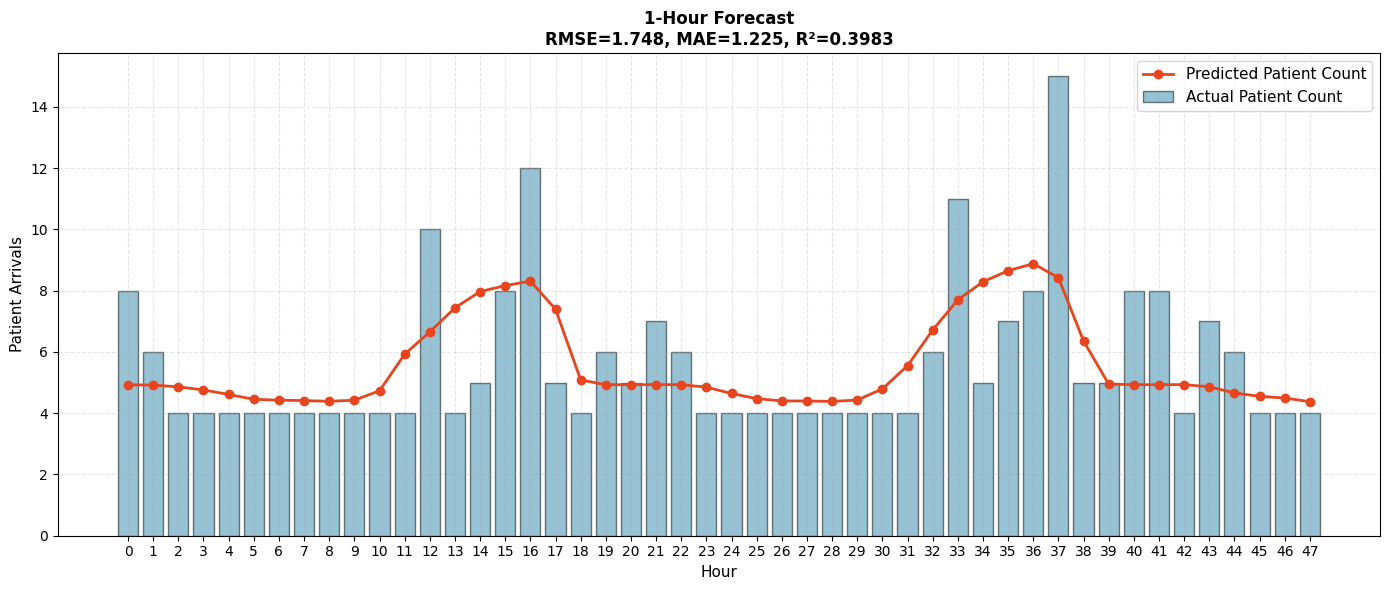

 Saved: forecast_2h.png


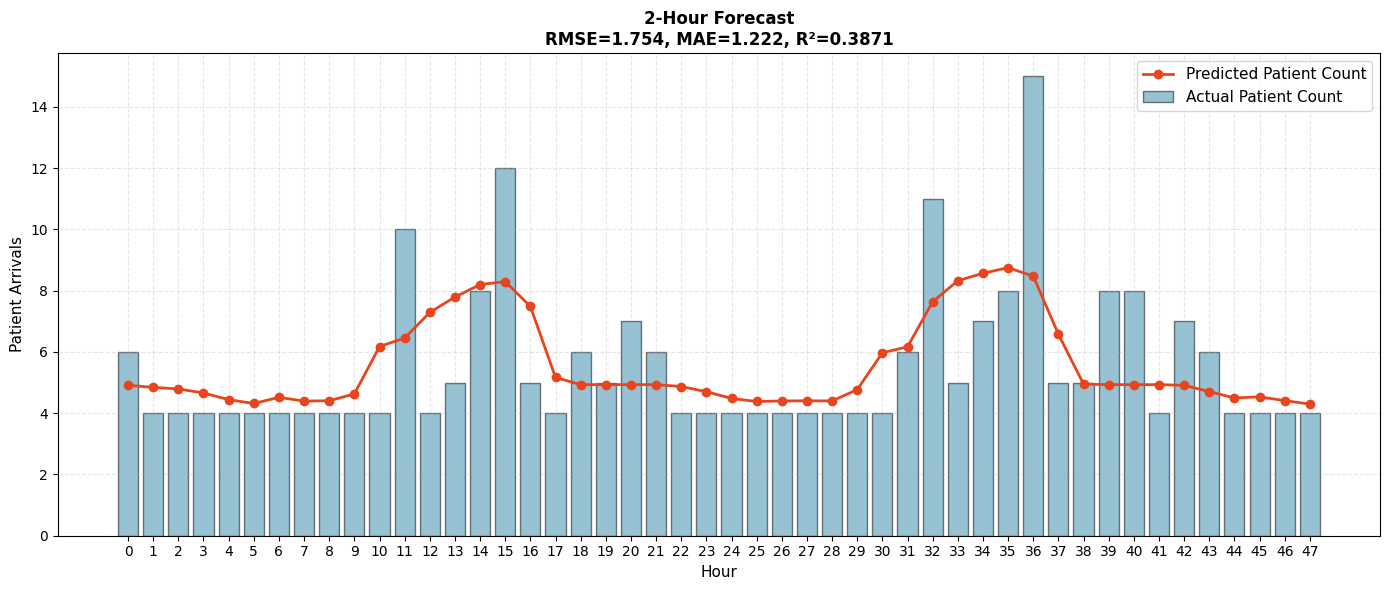

 Saved: forecast_6h.png


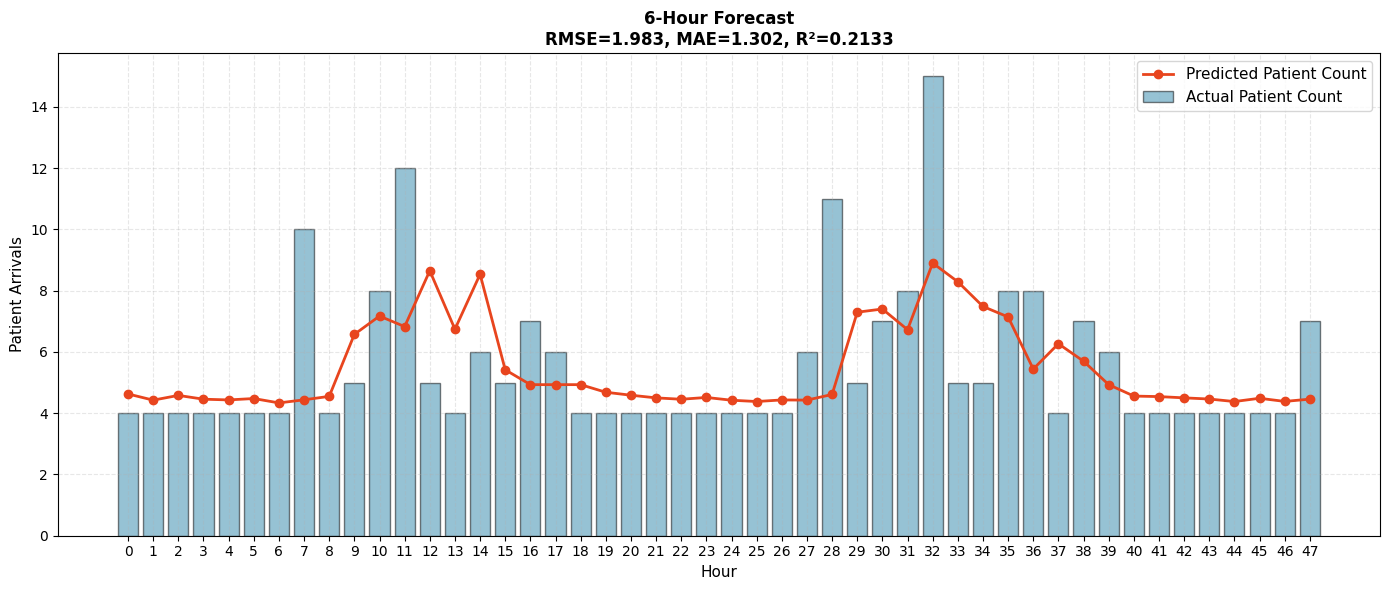

 Saved: forecast_12h.png


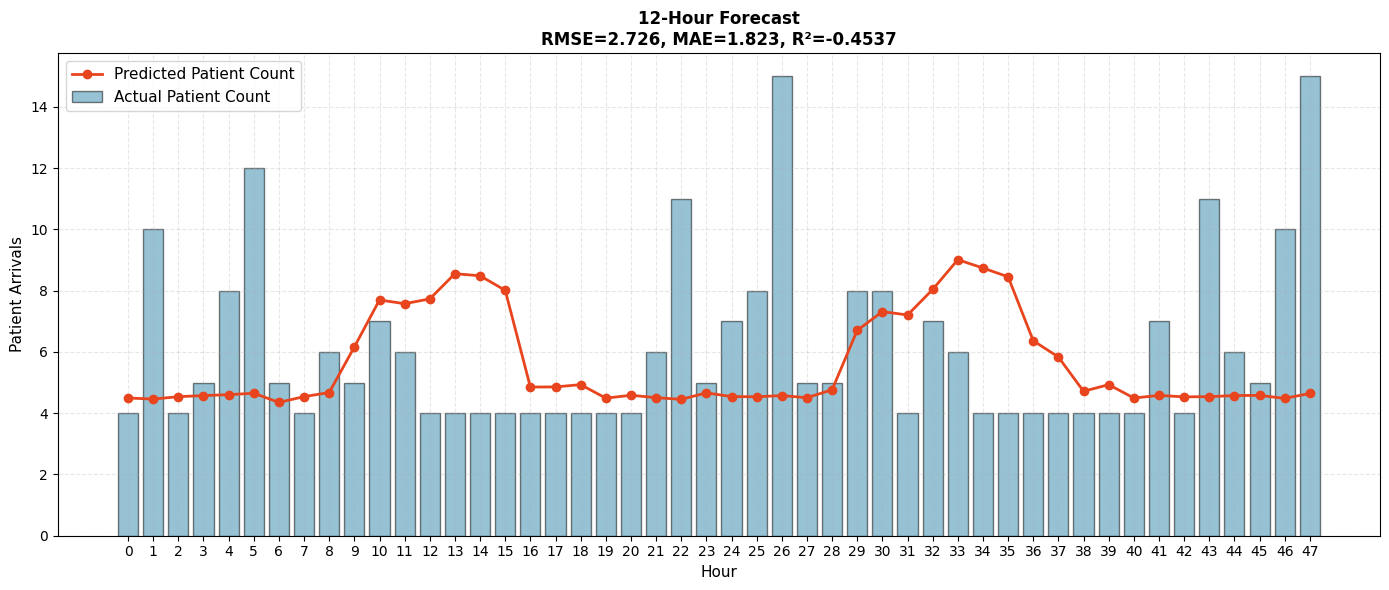

 Saved: forecast_24h.png


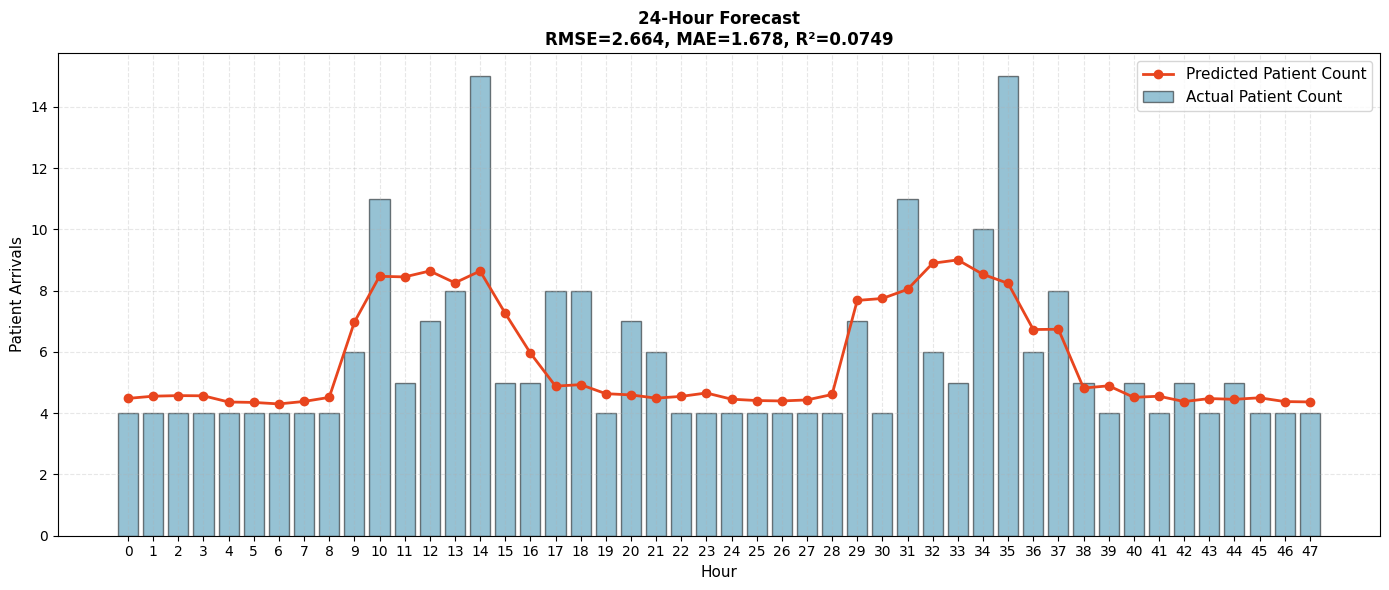

In [19]:
for horizon in [1, 2, 6, 12, 24]:
    fig, ax = plt.subplots(figsize=(14, 6))

    preds = results[horizon]['predictions'][:48]
    acts = results[horizon]['actuals'][:48]
    x = np.arange(len(preds))

    ax.bar(x, acts, alpha=0.5, label='Actual Patient Count',
           color='#2E86AB', edgecolor='black')
    ax.plot(x, preds, 'o-', label='Predicted Patient Count',
            color='#E8451E', linewidth=2, markersize=6)

    ax.set_xlabel('Hour', fontsize=11)
    ax.set_ylabel('Patient Arrivals', fontsize=11)
    ax.set_title(f'{horizon}-Hour Forecast\n'
                 f'RMSE={results[horizon]["rmse"]:.3f}, '
                 f'MAE={results[horizon]["mae"]:.3f}, '
                 f'R²={results[horizon]["r2"]:.4f}',
                 fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(x)

    plt.tight_layout()
    fig.savefig(f'forecast_{horizon}h.png', dpi=300, bbox_inches='tight')
    print(f" Saved: forecast_{horizon}h.png")
    plt.show()